In [1]:
from scipy.fft import fft

import numpy as np
from matplotlib import pyplot as plt
%config InlineBackend.figure_formats = ['svg']

import IPython.display as ipd


from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


With the minimum amplitude $A_\mathit{FS-}$ maximum ampitude $A_\mathit{FS+}$ and the number of quantization steps:

$$
\Delta_a = \frac{A_\mathit{FS-} - A_\mathit{FS+}}{N_{\mathit{steps}}} 
$$

$$
N_{\mathit{steps}} = 2^{N_{\mathit{bits}}}
$$

The plot below shows the quantization curve for a 3-bit quantizer - with 8 steps.


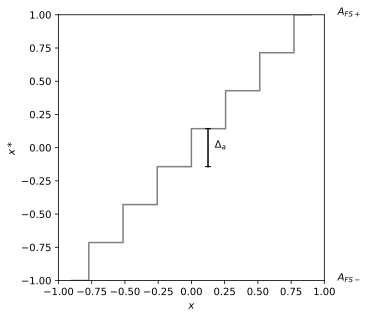

In [2]:
# 1000 Hz sampling rate
fs = 48000

# time vector with N samples length
N  = 2*fs
t  = np.linspace(0,N,N)/fs

f0 = 200

Nsteps = 8

x  = np.sin(2*np.pi*f0*t)
#x  = 2*(np.random.random(N)-0.5)
y  = np.zeros(N)
e  = np.zeros(N)

vals  = np.linspace(-0.9,0.9,Nsteps)
steps = np.linspace(-1,1,Nsteps)


fig,ax = plt.subplots()

ax.step(vals,steps,where='mid',color='gray')

plt.plot([0.125, 0.125],[steps[3],steps[4]],'k',markevery=[0,-1], marker='_')

plt.annotate("$\Delta_a$", xy=( 0.175,0))
plt.annotate("$A_\mathit{FS-}$", xy=( 1.1,-1), annotation_clip=False)
plt.annotate("$A_\mathit{FS+}$", xy=( 1.1,+1), annotation_clip=False)

ax.set_xlabel("$x$")
ax.set_ylabel("$x*$")

plt.axis('square')
plt.xlim([-1,1])
plt.ylim([-1,1])

#plt.grid()
plt.show()

Typical bit depths in the history of digital music:

- 8 bit has a very distinc distortion:
    - Fairlight CMI
    - LinnDrum
- 12 bit is still recognizable:
    - E-mu SP-1200 
- 16 bit has ben the standard for a long time and only causes artefacts in specific situations:
    - CD 
- 24 bit makes it almost unnecessary to worry about bit depth:
    - today's recording standard in most audio interfaces
- 32 bit ....
    - improved recording standard
    - representation in DAW's

-----

# Quantization Error

The quantization error $e$ is calculated as the difference between original and quantized signal:

$$
e = x-x*
$$



-----

## Probability Density of the Quantization Error



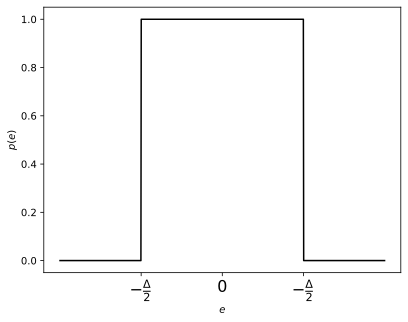

In [3]:

fig,ax = plt.subplots()
x = np.linspace(-1,1,1000)

y = np.zeros_like(x)   

y[250:750]=1

ax.plot(x,y,'k')
plt.xlabel('$e$')
plt.ylabel('$p(e)$')

plt.xticks([-0.5,0,0.5])
ax.set_xticklabels(['$-\\frac{\Delta}{2}$', 0,'$-\\frac{\Delta}{2}$'], fontsize=16);
 

-----

# Power of the Quantization Error

$$\begin{eqnarray}
W &=& \int_{-\Delta / 2}^{\Delta / 2} e^2 p(e) d e \\
&=& \frac{1}{\Delta} \int_{-\Delta / 2}^{\Delta / 2}  q^2 d e \\
&=& \frac{1}{\Delta}  \left[\frac{1}{3} q^3 \right]_{-\Delta / 2}^{\Delta / 2} \\
&=& \frac{1}{3 \Delta}  \left(\frac{\Delta^3}{8} + \frac{\Delta^3}{8} \right) \\
&=& \frac{\Delta^2}{12} 
\end{eqnarray}$$